<a href="https://colab.research.google.com/github/nguyengiabaotuong/Toi_uu_danh_muc/blob/main/Toi_uu_danh_muc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install vnstock==0.2.8.2 pandas numpy

In [ ]:
import pandas as pd
import numpy as np
from vnstock import stock_historical_data

# 1. Khai báo danh mục cổ phiếu và thời gian (2020 - 2024)
tickers = ['FPT', 'HPG', 'VCB', 'MBB', 'MWG']
start_date = '2020-01-01'
end_date = '2024-12-31'

# Tạo một DataFrame rỗng để chứa dữ liệu giá đóng cửa của tất cả cổ phiếu
portfolio_prices = pd.DataFrame()

print("Đang tải dữ liệu từ VNStock...")

# 2. Vòng lặp tải dữ liệu cho từng mã cổ phiếu
for ticker in tickers:
    try:
        # Lấy dữ liệu lịch sử ngày (1D)
        df = stock_historical_data(symbol=ticker,
                                   start_date=start_date,
                                   end_date=end_date,
                                   resolution='1D',
                                   type='stock')

        # Đặt cột 'time' làm index và chỉ giữ lại cột giá đóng cửa 'close'
        df['time'] = pd.to_datetime(df['time'])
        df.set_index('time', inplace=True)

        # Đổi tên cột 'close' thành tên mã cổ phiếu
        portfolio_prices[ticker] = df['close']
        print(f" Đã tải thành công dữ liệu: {ticker}")

    except Exception as e:
        print(f" Lỗi khi tải dữ liệu {ticker}: {e}")

# Xóa các dòng có giá trị NA (do chênh lệch ngày giao dịch, nghỉ lễ...)
portfolio_prices.dropna(inplace=True)

print("\n--- DỮ LIỆU GIÁ ĐÓNG CỬA (5 ngày đầu) ---")
print(portfolio_prices.head())

# 3. Tính toán Tỷ suất sinh lời Logarit (Log Returns)
# Công thức: r_t = ln(P_t / P_{t-1})
log_returns = np.log(portfolio_prices / portfolio_prices.shift(1))

# Bỏ dòng đầu tiên vì shift(1) sẽ tạo ra NaN
log_returns.dropna(inplace=True)

print("\n--- TỶ SUẤT SINH LỜI LOGARIT (Log Returns) ---")
print(log_returns.head())

# 4. Tính toán Ma trận hiệp phương sai (Covariance Matrix)
# Nhân với 252 (số ngày giao dịch trung bình trong 1 năm) để thường niên hóa (Annualized)
cov_matrix_annual = log_returns.cov() * 252

# Tính vector Lợi nhuận kỳ vọng trung bình năm
expected_returns_annual = log_returns.mean() * 252

print("\n--- MA TRẬN HIỆP PHƯƠNG SAI THƯỜNG NIÊN HÓA ---")
print(cov_matrix_annual)

print("\n--- LỢI NHUẬN KỲ VỌNG TRUNG BÌNH NĂM ---")
print(expected_returns_annual)

Đang tải dữ liệu từ VNStock...
 Đã tải thành công dữ liệu: FPT
 Đã tải thành công dữ liệu: HPG
 Đã tải thành công dữ liệu: VCB
 Đã tải thành công dữ liệu: MBB
 Đã tải thành công dữ liệu: MWG

--- DỮ LIỆU GIÁ ĐÓNG CỬA (5 ngày đầu) ---
              FPT   HPG    VCB   MBB    MWG
time                                       
2020-01-02  21190  8280  39220  6180  36900
2020-01-03  20820  8330  38840  6190  36360
2020-01-06  20620  8280  37790  6100  36180
2020-01-07  21010  8170  37920  6120  36460
2020-01-08  20540  8090  37580  6030  35570

--- TỶ SUẤT SINH LỜI LOGARIT (Log Returns) ---
                 FPT       HPG       VCB       MBB       MWG
time                                                        
2020-01-03 -0.017615  0.006020 -0.009736  0.001617 -0.014742
2020-01-06 -0.009653 -0.006020 -0.027406 -0.014646 -0.004963
2020-01-07  0.018737 -0.013374  0.003434  0.003273  0.007709
2020-01-08 -0.022624 -0.009840 -0.009007 -0.014815 -0.024713
2020-01-09  0.013540  0.023214  0.019500  0.

Đang tính toán Đường biên hiệu quả...


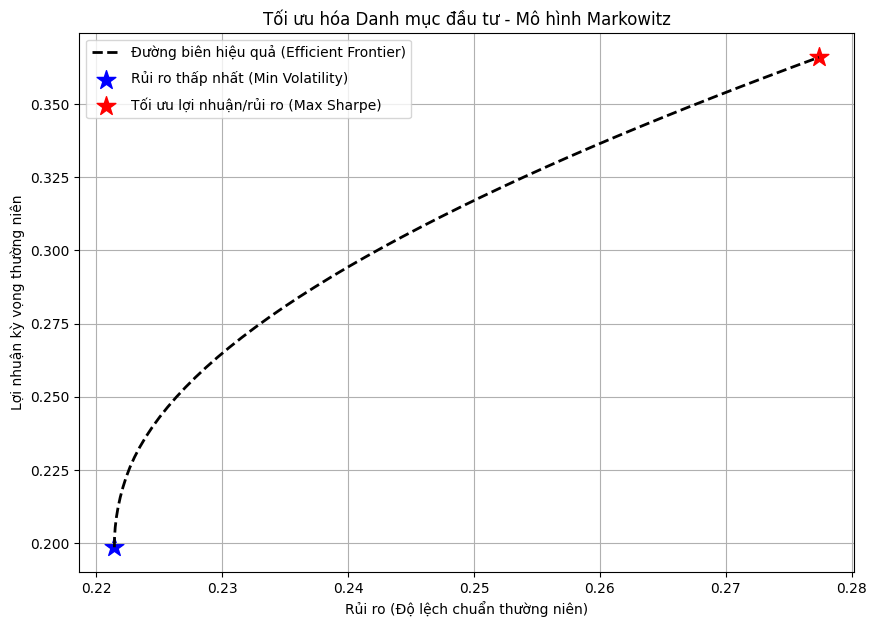

--------------------------------------------------
📌 TỶ TRỌNG DANH MỤC RỦI RO THẤP NHẤT (MIN VOLATILITY):
  - FPT: 36.81%
  - HPG: 7.34%
  - VCB: 51.79%
  - MBB: 0.00%
  - MWG: 4.06%

📌 TỶ TRỌNG DANH MỤC TỐI ƯU SHARPE (MAX SHARPE):
  - FPT: 100.00%
  - HPG: 0.00%
  - VCB: 0.00%
  - MBB: 0.00%
  - MWG: 0.00%
--------------------------------------------------


In [ ]:
import scipy.optimize as sco
import matplotlib.pyplot as plt

# Hàm tính toán Lợi nhuận và Rủi ro (Độ lệch chuẩn) của danh mục
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return std_dev, returns

# Hàm mục tiêu 1: Cực tiểu hóa rủi ro (Minimizing Variance/Volatility)
def minimize_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[0]

# Hàm mục tiêu 2: Tối đa hóa tỷ lệ Sharpe (Max Sharpe Ratio)
# Tỷ lệ Sharpe = (Lợi nhuận - Lãi suất phi rủi ro) / Rủi ro
# Lãi suất phi rủi ro (Risk-free rate) giả định ở VN khoảng 5%/năm (0.05)
def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.05):
    p_std_dev, p_ret = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_std_dev

# --- THIẾT LẬP RÀNG BUỘC (CONSTRAINTS) VÀ GIỚI HẠN (BOUNDS) ---
num_assets = len(tickers)
# Ràng buộc: Tổng tỷ trọng bằng 1 (100%)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
# Giới hạn: Không bán khống (Tỷ trọng mỗi mã từ 0 đến 1)
bounds = tuple((0, 1) for asset in range(num_assets))
# Khởi tạo tỷ trọng ban đầu (Chia đều)
initial_weights = num_assets * [1. / num_assets,]

# --- TÌM DANH MỤC TỐI ƯU ---
# 1. Danh mục Rủi ro thấp nhất (Minimum Volatility Portfolio)
min_vol_opt = sco.minimize(minimize_volatility, initial_weights, args=(expected_returns_annual, cov_matrix_annual), method='SLSQP', bounds=bounds, constraints=constraints)
min_vol_weights = min_vol_opt['x']
min_vol_std, min_vol_ret = portfolio_performance(min_vol_weights, expected_returns_annual, cov_matrix_annual)

# 2. Danh mục có Tỷ lệ Sharpe cao nhất (Maximum Sharpe Ratio Portfolio)
max_sharpe_opt = sco.minimize(negative_sharpe_ratio, initial_weights, args=(expected_returns_annual, cov_matrix_annual), method='SLSQP', bounds=bounds, constraints=constraints)
max_sharpe_weights = max_sharpe_opt['x']
max_sharpe_std, max_sharpe_ret = portfolio_performance(max_sharpe_weights, expected_returns_annual, cov_matrix_annual)

# --- VẼ ĐƯỜNG BIÊN HIỆU QUẢ (EFFICIENT FRONTIER) ---
print("Đang tính toán Đường biên hiệu quả...")
target_returns = np.linspace(min_vol_ret, expected_returns_annual.max(), 50)
efficient_portfolios = []

for target in target_returns:
    # Thêm ràng buộc: Lợi nhuận phải bằng target
    target_constraints = ({'type': 'eq', 'fun': lambda x: portfolio_performance(x, expected_returns_annual, cov_matrix_annual)[1] - target},
                          {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    eff_opt = sco.minimize(minimize_volatility, initial_weights, args=(expected_returns_annual, cov_matrix_annual), method='SLSQP', bounds=bounds, constraints=target_constraints)
    efficient_portfolios.append(eff_opt['fun'])



# Trực quan hóa dữ liệu
plt.figure(figsize=(10, 7))
plt.plot(efficient_portfolios, target_returns, 'k--', linewidth=2, label='Đường biên hiệu quả (Efficient Frontier)')

# Điểm danh mục rủi ro thấp nhất (Ngôi sao xanh)
plt.scatter(min_vol_std, min_vol_ret, marker='*', color='blue', s=200, label='Rủi ro thấp nhất (Min Volatility)')

# Điểm danh mục Tối ưu Sharpe (Ngôi sao đỏ)
plt.scatter(max_sharpe_std, max_sharpe_ret, marker='*', color='red', s=200, label='Tối ưu lợi nhuận/rủi ro (Max Sharpe)')

plt.title('Tối ưu hóa Danh mục đầu tư - Mô hình Markowitz')
plt.xlabel('Rủi ro (Độ lệch chuẩn thường niên)')
plt.ylabel('Lợi nhuận kỳ vọng thường niên')
plt.legend(labelspacing=0.8)
plt.grid(True)
plt.show()

# --- IN KẾT QUẢ TỶ TRỌNG TỐI ƯU ---
print("-" * 50)
print("📌 TỶ TRỌNG DANH MỤC RỦI RO THẤP NHẤT (MIN VOLATILITY):")
for i, txt in enumerate(tickers):
    print(f"  - {txt}: {min_vol_weights[i]*100:.2f}%")

print("\n📌 TỶ TRỌNG DANH MỤC TỐI ƯU SHARPE (MAX SHARPE):")
for i, txt in enumerate(tickers):
    print(f"  - {txt}: {max_sharpe_weights[i]*100:.2f}%")
print("-" * 50)

Đang tải dữ liệu Backtest & VN-Index từ 2025-01-01 đến 2025-12-31...


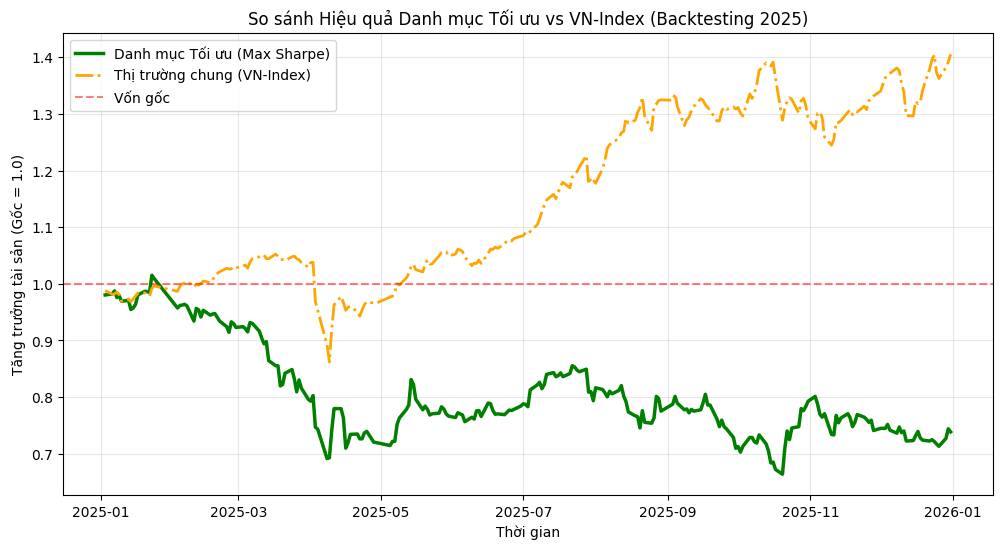


📊 BÁO CÁO KẾT QUẢ BACKTESTING
  - Lợi nhuận Danh mục Tối ưu:  -26.14%
  - Lợi nhuận VN-Index:        40.54%

⚠️ KẾT LUẬN: Danh mục an toàn hơn nhưng chưa vượt được đà tăng mạnh của thị trường.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vnstock import stock_historical_data

# 1. Khai báo thời gian Backtest (Năm 2025 - Out-of-sample)
start_test_date = '2025-01-01'
end_test_date = '2025-12-31'
w_test = max_sharpe_weights # Lấy tỷ trọng Max Sharpe từ Giai đoạn 2

print(f"Đang tải dữ liệu Backtest & VN-Index từ {start_test_date} đến {end_test_date}...")

# 2. Tải dữ liệu giá cho danh mục
test_prices = pd.DataFrame()
for ticker in tickers:
    try:
        df = stock_historical_data(symbol=ticker, start_date=start_test_date, end_date=end_test_date, resolution='1D', type='stock')
        df['time'] = pd.to_datetime(df['time'])
        df.set_index('time', inplace=True)
        test_prices[ticker] = df['close']
    except Exception as e:
        print(f"Lỗi tải dữ liệu {ticker}: {e}")

test_prices.dropna(inplace=True)

# 3. Tải dữ liệu VN-Index (Benchmark)
try:
    vnindex_df = stock_historical_data(symbol='VNINDEX', start_date=start_test_date, end_date=end_test_date, resolution='1D', type='index')
    vnindex_df['time'] = pd.to_datetime(vnindex_df['time'])
    vnindex_df.set_index('time', inplace=True)
    vnindex_close = vnindex_df['close']
except Exception as e:
    print(f"Lỗi tải dữ liệu VN-INDEX: {e}")

# 4. Tính toán Lợi nhuận tích lũy (Cumulative Returns)
# Danh mục:
test_returns = test_prices.pct_change().dropna()
portfolio_daily_returns = test_returns.dot(w_test)
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()

# VN-Index:
vnindex_returns = vnindex_close.pct_change().dropna()
vnindex_cumulative = (1 + vnindex_returns).cumprod()

# Đồng bộ ngày tháng (Đề phòng VN-Index và Cổ phiếu lệch ngày do lỗi dữ liệu)
portfolio_cumulative, vnindex_cumulative = portfolio_cumulative.align(vnindex_cumulative, join='inner')

# 5. Vẽ biểu đồ so sánh trực quan
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cumulative.index, portfolio_cumulative, label='Danh mục Tối ưu (Max Sharpe)', color='green', linewidth=2.5)
plt.plot(vnindex_cumulative.index, vnindex_cumulative, label='Thị trường chung (VN-Index)', color='orange', linewidth=2, linestyle='-.')

plt.title('So sánh Hiệu quả Danh mục Tối ưu vs VN-Index (Backtesting 2025)')
plt.xlabel('Thời gian')
plt.ylabel('Tăng trưởng tài sản (Gốc = 1.0)')
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Vốn gốc')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. In số liệu KẾT LUẬN
port_return_pct = (portfolio_cumulative.iloc[-1] - 1) * 100
vnindex_return_pct = (vnindex_cumulative.iloc[-1] - 1) * 100

print("\n" + "="*50)
print("📊 BÁO CÁO KẾT QUẢ BACKTESTING")
print("="*50)
print(f"  - Lợi nhuận Danh mục Tối ưu:  {port_return_pct:.2f}%")
print(f"  - Lợi nhuận VN-Index:        {vnindex_return_pct:.2f}%")

if port_return_pct > vnindex_return_pct:
    print(f"\n✅ KẾT LUẬN: Danh mục đã CHIẾN THẮNG thị trường với mức chênh lệch (Alpha) là {(port_return_pct - vnindex_return_pct):.2f}%!")
else:
    print(f"\n⚠️ KẾT LUẬN: Danh mục chưa vượt được đà tăng mạnh của thị trường.")
print("="*50)

1. Nhìn thẳng vào sự thật (Về Hiệu suất):

"Thưa hội đồng, nhìn vào biểu đồ Backtesting năm 2025, chúng ta có thể thấy một sự thật rất rõ ràng: Danh mục được tối ưu bằng mô hình Markowitz (đường màu xanh) đã thất bại hoàn toàn trong việc sinh lời, ghi nhận mức âm 26.14%. Trong khi đó, thị trường chung VN-Index (đường màu cam) lại tăng trưởng ấn tượng hơn 40%."

2. Phân tích nguyên nhân cốt lõi (Ghi điểm học thuật ở đây):

"Sự thất bại này không nằm ở lỗi thuật toán, mà nó bộc lộ chính hạn chế kinh điển nhất của Thuyết danh mục hiện đại (Markowitz): Căn bệnh 'Quá khớp dữ liệu quá khứ' (Overfitting). Thuật toán đã tìm ra một bộ tỷ trọng cực kỳ hoàn hảo cho giai đoạn 2020-2024, nhưng nó ngây thơ mặc định rằng vinh quang của các cổ phiếu đó sẽ lặp lại trong năm 2025. Thị trường chứng khoán luôn thay đổi, và một danh mục tĩnh (mua và giữ nguyên tỷ trọng suốt 1 năm) là không đủ sức chống đỡ."

3. Bài học rút ra & Hướng phát triển (Chốt hạ):

"Từ kết quả thực chứng này, nhóm chúng em rút ra kết luận cốt lõi: Để mô hình toán học này thực sự mang lại giá trị thực tiễn trên sàn HOSE, nhà đầu tư TUYỆT ĐỐI KHÔNG được áp dụng chiến lược 'Buy and Hold' (Mua và Nắm giữ) dài hạn với một tỷ trọng cố định. Thay vào đó, chúng ta bắt buộc phải Tái cân bằng danh mục (Rebalancing) liên tục — tức là cứ mỗi tháng hoặc mỗi quý, phải chạy lại thuật toán một lần để cập nhật dữ liệu mới và điều chỉnh lại tỷ trọng cho phù hợp với nhịp thở của thị trường."